In [126]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [127]:
!pip install xlrd

In [128]:
df = pd.read_excel("Data\sample_-_superstore.xls")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [129]:
df.shape

(9994, 21)

In [130]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [131]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [132]:
df["Year"]=df["Order Date"].dt.year

In [133]:
df["Month"]=df["Order Date"].dt.month

In [134]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10


In [135]:
df.shape

(9994, 23)

In [136]:
df["Month_Year"]=df["Order Date"].dt.to_period("M")

In [137]:
df[["Order Date","Month_Year"]].head()

,Order Date,Month_Year
0,2016-11-08,2016-11
1,2016-11-08,2016-11
2,2016-06-12,2016-06
3,2015-10-11,2015-10
4,2015-10-11,2015-10


In [138]:
monthly_sales= df.groupby("Month_Year")["Sales"].sum()

In [139]:
monthly_sales.head().sort_values(ascending=False)

Month_Year
2014-03    55691.009
2014-04    28295.345
2014-05    23648.287
2014-01    14236.895
2014-02     4519.892
Freq: M, Name: Sales, dtype: float64

In [140]:
type(monthly_sales)

pandas.core.series.Series

In [141]:
monthly_sales.tail()

Month_Year
2017-08     63120.8880
2017-09     87866.6520
2017-10     77776.9232
2017-11    118447.8250
2017-12     83829.3188
Freq: M, Name: Sales, dtype: float64

In [142]:
monthly_sales.shape

(48,)

In [143]:
monthly_sales=monthly_sales.sort_index()

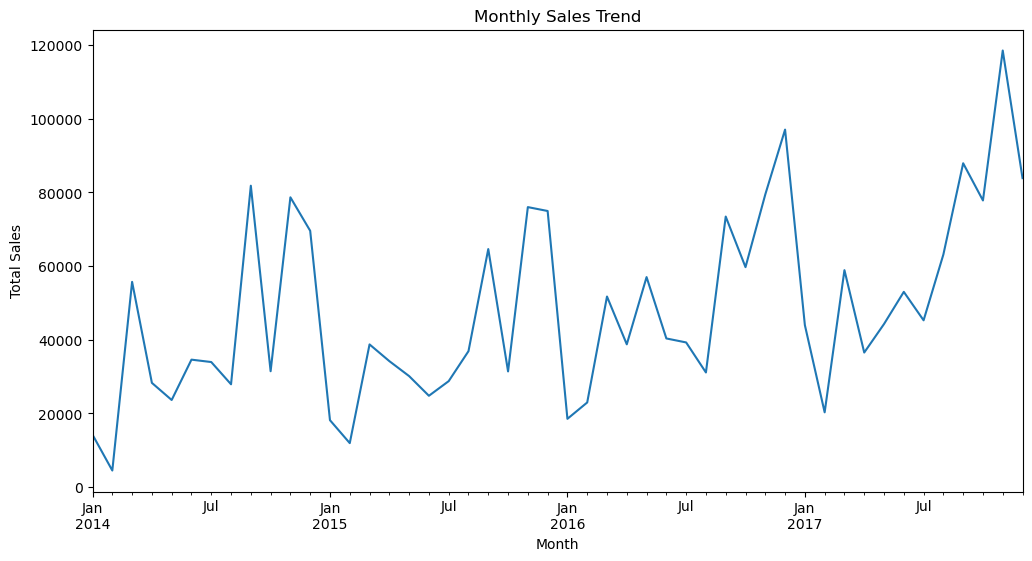

In [144]:
monthly_sales.plot(figsize=(12,6))
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.savefig("outputs/charts/monthly_sales.png")
plt.show()

### Business Insight

Sales show fluctuations across months, indicating possible seasonal demand patterns.

In [145]:
profit_by_region= df.groupby("Region")["Profit"].sum()

In [146]:
profit_by_region.sort_values(ascending=False)

Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64

### Business Insight

The West region generates the highest profit (~108K), while the Central region shows the lowest (~39K), indicating potential regional inefficiencies.

In [147]:
Product_sales= df.groupby("Product Name")["Sales"].sum()

In [148]:
Product_sales.head()

Product Name
"While you Were Out" Message Book, One Form per Page     25.228
#10 Gummed Flap White Envelopes, 100/Box                 41.300
#10 Self-Seal White Envelopes                           108.682
#10 White Business Envelopes,4 1/8 x 9 1/2              488.904
#10- 4 1/8" x 9 1/2" Recycled Envelopes                 286.672
Name: Sales, dtype: float64

In [149]:
Product_sales=Product_sales.sort_values(ascending=False)

In [150]:
Product_sales.head()

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
Name: Sales, dtype: float64

In [151]:
top_products=Product_sales.head(10)
top_products

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

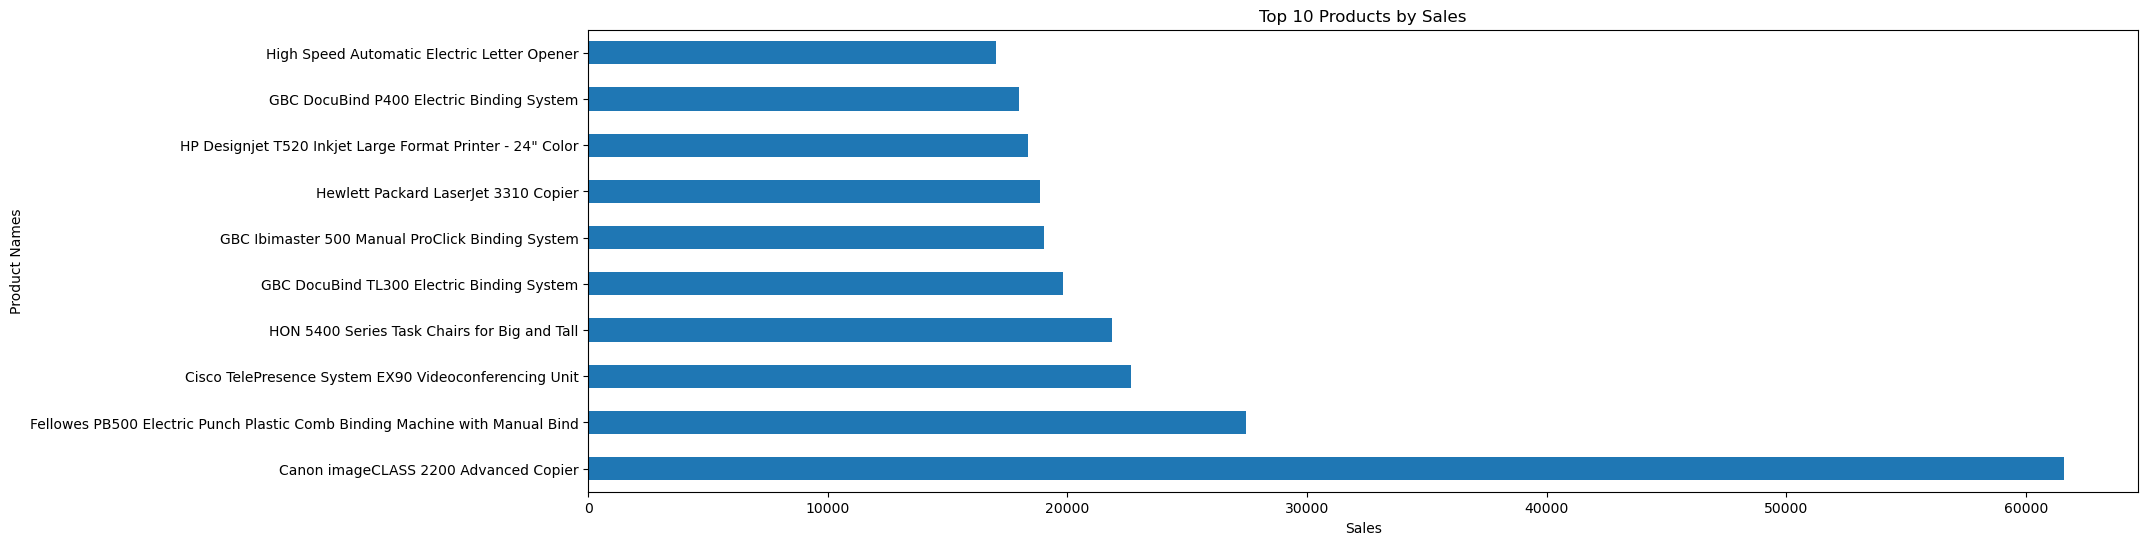

In [171]:
top_products.plot(kind="barh",figsize=(20,6))
plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product Names")
plt.savefig("outputs/charts/top_products.png")
plt.show()

### Business Insight

The top 10 products contribute a significant portion of total revenue, indicating that sales are concentrated among a small number of high-performing products. This suggests an opportunity to focus marketing, inventory, and pricing strategies on these key products to maximize revenue.

In [153]:
customer_sales=df.groupby("Customer ID")["Sales"].sum()

In [154]:
customer_sales.head()

Customer ID
AA-10315    5563.560
AA-10375    1056.390
AA-10480    1790.512
AA-10645    5086.935
AB-10015     886.156
Name: Sales, dtype: float64

In [155]:
customer_sales=customer_sales.sort_values(ascending=False)
customer_sales

Customer ID
SM-20320    25043.050
TC-20980    19052.218
RB-19360    15117.339
TA-21385    14595.620
AB-10105    14473.571
              ...    
RS-19870       22.328
MG-18205       16.739
CJ-11875       16.520
LD-16855        5.304
TS-21085        4.833
Name: Sales, Length: 793, dtype: float64

In [156]:
customer_segment=pd.qcut(customer_sales,q=3,labels=["Low","Medium","High"])

In [157]:
customer_df=pd.DataFrame({"Sales":customer_sales,"Segment":customer_segment})

In [158]:
customer_df.head()

,Sales,Segment
Customer ID,,
SM-20320,25043.050,High
TC-20980,19052.218,High
RB-19360,15117.339,High
TA-21385,14595.620,High
AB-10105,14473.571,High


In [159]:
customer_df["Segment"].value_counts()

Segment
Low       265
High      265
Medium    263
Name: count, dtype: int64

In [160]:
customer_df.groupby("Segment", observed=False)["Sales"].sum().sort_values(ascending=False)

Segment
High      1.489379e+06
Medium    5.951112e+05
Low       2.127111e+05
Name: Sales, dtype: float64

### Business Insight

High-value customers contribute ~65% of total revenue, showing strong revenue concentration among a small customer base.

In [161]:
customer_df.to_excel("outputs/reports/customer_segments.xlsx")

In [162]:
profit_by_region.to_excel("outputs/reports/profit_by_region.xlsx")

In [163]:
top_products_df = top_products.reset_index()
top_products_df.to_excel("outputs/reports/top_products.xlsx")

In [164]:
monthly_sales_df=monthly_sales.reset_index()
monthly_sales_df.to_excel("outputs/reports/monthly_sales.xlsx")